---
title: "Autocorre"
author: "Harlow Malloc"
date: "2026-05-05"
categories: [ code, analysis,autocorrelation]
image: "OIP-574833120.jpg"
---

In [49]:
import requests
import pandas as pd
import seaborn as sns
url = "https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/IPC206449?nult=200"

In [50]:
respuesta = requests.get(url)
print(respuesta.status_code)
print(respuesta.json())

200
{'COD': 'IPC206449', 'Nombre': 'Nacional. Índice general. Variación mensual. ', 'FK_Unidad': 135, 'FK_Escala': 1, 'Data': [{'Fecha': 1114898400000, 'FK_TipoDato': 1, 'FK_Periodo': 5, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}, {'Fecha': 1117576800000, 'FK_TipoDato': 1, 'FK_Periodo': 6, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}, {'Fecha': 1120168800000, 'FK_TipoDato': 1, 'FK_Periodo': 7, 'Anyo': 2005, 'Valor': -0.6, 'Secreto': False}, {'Fecha': 1122847200000, 'FK_TipoDato': 1, 'FK_Periodo': 8, 'Anyo': 2005, 'Valor': 0.4, 'Secreto': False}, {'Fecha': 1125525600000, 'FK_TipoDato': 1, 'FK_Periodo': 9, 'Anyo': 2005, 'Valor': 0.6, 'Secreto': False}, {'Fecha': 1128117600000, 'FK_TipoDato': 1, 'FK_Periodo': 10, 'Anyo': 2005, 'Valor': 0.8, 'Secreto': False}, {'Fecha': 1130799600000, 'FK_TipoDato': 1, 'FK_Periodo': 11, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}, {'Fecha': 1133391600000, 'FK_TipoDato': 1, 'FK_Periodo': 12, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}, {'Fecha': 113

In [51]:
datos_json = respuesta.json()
print(type(datos_json))

<class 'dict'>


In [52]:
print(datos_json.keys())

dict_keys(['COD', 'Nombre', 'FK_Unidad', 'FK_Escala', 'Data'])


In [53]:
print(datos_json['Data'][0])
print(datos_json['Data'][1])

{'Fecha': 1114898400000, 'FK_TipoDato': 1, 'FK_Periodo': 5, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}
{'Fecha': 1117576800000, 'FK_TipoDato': 1, 'FK_Periodo': 6, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}


In [54]:
Electricidad = pd.DataFrame.from_dict(datos_json['Data'])

In [55]:
print(Electricidad.head())
print(Electricidad.shape)

           Fecha  FK_TipoDato  FK_Periodo  Anyo  Valor  Secreto Notas
0  1114898400000            1           5  2005    0.2    False   NaN
1  1117576800000            1           6  2005    0.2    False   NaN
2  1120168800000            1           7  2005   -0.6    False   NaN
3  1122847200000            1           8  2005    0.4    False   NaN
4  1125525600000            1           9  2005    0.6    False   NaN
(200, 7)


In [56]:
Electricidad.columns = ["fecha","fk_dt","fk_period","ano","valor","secreto","notas"]

In [57]:
df_elec = Electricidad[["ano","fk_period", "valor"]]

In [58]:
df_elec.head()

,ano,fk_period,valor
0,2005,5,0.2
1,2005,6,0.2
2,2005,7,-0.6
3,2005,8,0.4
4,2005,9,0.6


# Temperature data

In [59]:
url_temp = "https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/IPC206450?nult=200"
respuesta_temp = requests.get(url_temp)
print(respuesta_temp.status_code)

200


In [60]:
temp_dict = respuesta_temp.json()

In [61]:
temp_df = pd.DataFrame.from_dict(temp_dict['Data'])

In [62]:
temp_df = temp_df[["Anyo","FK_Periodo","Valor"]]

In [63]:
temp_df.columns=["ano","fk_period","valor"]

In [64]:
df= df_elec.merge(temp_df, left_on = ["ano","fk_period"],right_on = ["ano", "fk_period"])

In [65]:
df.columns = ["ano", "fk_period", "electricidad", "temperatura"]

In [66]:
df

,ano,fk_period,electricidad,temperatura
0,2005,5,0.2,2.7
1,2005,6,0.2,2.9
2,2005,7,-0.6,2.7
3,2005,8,0.4,2.7
4,2005,9,0.6,2.9
...,...,...,...,...
195,2021,8,0.5,0.7
196,2021,9,0.8,0.7
197,2021,10,1.8,0.9
198,2021,11,0.3,1.4


In [67]:
import seaborn as sns

In [68]:
df

,ano,fk_period,electricidad,temperatura
0,2005,5,0.2,2.7
1,2005,6,0.2,2.9
2,2005,7,-0.6,2.7
3,2005,8,0.4,2.7
4,2005,9,0.6,2.9
...,...,...,...,...
195,2021,8,0.5,0.7
196,2021,9,0.8,0.7
197,2021,10,1.8,0.9
198,2021,11,0.3,1.4


In [69]:
df

,ano,fk_period,electricidad,temperatura
0,2005,5,0.2,2.7
1,2005,6,0.2,2.9
2,2005,7,-0.6,2.7
3,2005,8,0.4,2.7
4,2005,9,0.6,2.9
...,...,...,...,...
195,2021,8,0.5,0.7
196,2021,9,0.8,0.7
197,2021,10,1.8,0.9
198,2021,11,0.3,1.4


In [72]:
df['fecha'] = pd.to_datetime(df['ano'].astype(str)+'-'+df['fk_period'].astype(str))
print(df['fecha'].head())

0   2005-05-01
1   2005-06-01
2   2005-07-01
3   2005-08-01
4   2005-09-01
Name: fecha, dtype: datetime64[ns]


In [74]:
df

,ano,fk_period,electricidad,temperatura,fecha
0,2005,5,0.2,2.7,2005-05-01
1,2005,6,0.2,2.9,2005-06-01
2,2005,7,-0.6,2.7,2005-07-01
3,2005,8,0.4,2.7,2005-08-01
4,2005,9,0.6,2.9,2005-09-01
...,...,...,...,...,...
195,2021,8,0.5,0.7,2021-08-01
196,2021,9,0.8,0.7,2021-09-01
197,2021,10,1.8,0.9,2021-10-01
198,2021,11,0.3,1.4,2021-11-01


<Axes: xlabel='fecha', ylabel='electricidad'>

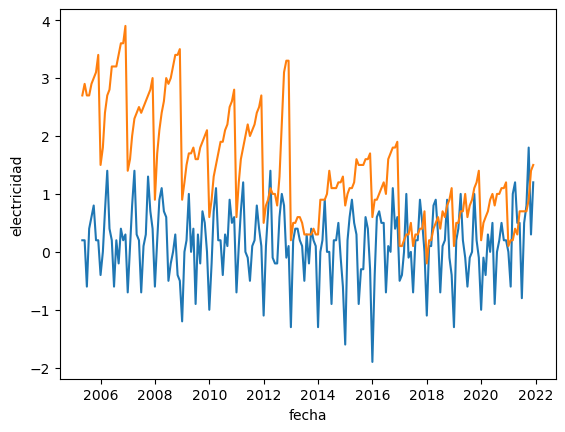

In [73]:
sns.lineplot(data = df,x = 'fecha', y = 'electricidad')
sns.lineplot(data = df,x = 'fecha', y = 'temperatura')

In [84]:
import numpy as np
import statsmodels.api as sm
import statsmodels as sm

In [76]:
spector_data = sm.datasets.spector.load()

In [77]:
df = sm.add_constant(df, prepend = False)

In [78]:
df

,ano,fk_period,electricidad,temperatura,fecha,const
0,2005,5,0.2,2.7,2005-05-01,1.0
1,2005,6,0.2,2.9,2005-06-01,1.0
2,2005,7,-0.6,2.7,2005-07-01,1.0
3,2005,8,0.4,2.7,2005-08-01,1.0
4,2005,9,0.6,2.9,2005-09-01,1.0
...,...,...,...,...,...,...
195,2021,8,0.5,0.7,2021-08-01,1.0
196,2021,9,0.8,0.7,2021-09-01,1.0
197,2021,10,1.8,0.9,2021-10-01,1.0
198,2021,11,0.3,1.4,2021-11-01,1.0


In [79]:
#fit and summarise model
mod = sm.OLS(df.electricidad, df.temperatura)

In [80]:
res = mod.fit()

In [81]:
print(res.summary())

                                 OLS Regression Results                                
Dep. Variable:           electricidad   R-squared (uncentered):                   0.095
Model:                            OLS   Adj. R-squared (uncentered):              0.090
Method:                 Least Squares   F-statistic:                              20.82
Date:                Wed, 06 May 2026   Prob (F-statistic):                    8.80e-06
Time:                        13:34:51   Log-Likelihood:                         -178.88
No. Observations:                 200   AIC:                                      359.8
Df Residuals:                     199   BIC:                                      363.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [90]:
test_BG = sm.stats.diagnostic.acorr_breusch_godfrey(res, nlags=12, store=False)

In [91]:
test_BG

(123.54663523963794,
 1.2106545252171951e-20,
 25.006641698023305,
 9.998827530532864e-33)

In [92]:
print("LM: ",test_BG[0])
print("p-value: ",test_BG[1])
print("F-test: ",test_BG[2])
print("p-value F-test: ",test_BG[3])


LM:  123.54663523963794
p-value:  1.2106545252171951e-20
F-test:  25.006641698023305
p-value F-test:  9.998827530532864e-33


In [94]:
res_hac = res.get_robustcov_results(
    cov_type = "HAC",
    maxlags = 12
)

In [96]:
print(res_hac.summary())

                                 OLS Regression Results                                
Dep. Variable:           electricidad   R-squared (uncentered):                   0.095
Model:                            OLS   Adj. R-squared (uncentered):              0.090
Method:                 Least Squares   F-statistic:                              27.89
Date:                Wed, 06 May 2026   Prob (F-statistic):                    3.36e-07
Time:                        13:53:22   Log-Likelihood:                         -178.88
No. Observations:                 200   AIC:                                      359.8
Df Residuals:                     199   BIC:                                      363.1
Df Model:                           1                                                  
Covariance Type:                  HAC                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [101]:
import statsmodels.api as sma


In [104]:
#Heterocedastic test 
exog_con_constante = sma.add_constant(df['temperatura'])
het_test = sm.stats.diagnostic.het_breuschpagan(
    res_hac.resid, 
    exog_het = exog_con_constante,
    robust = True
)

In [105]:
het_test

(5.700367182679744,
 0.016961364258443776,
 5.808928641835176,
 0.016859476939943496)

In [115]:
from statsmodels.iolib.summary2 import summary_col
table = summary_col([res, res_hac])

In [116]:
table.columns = ["OLS", "OLS_HAC"]

In [119]:
summary_col([res,res_hac], model_names = ["ols", "ols_hac"])

,ols,ols_hac
temperatura,0.1101,0.1101
,(0.0241),(0.0209)
R-squared,0.0947,0.0947
R-squared Adj.,0.0902,0.0902


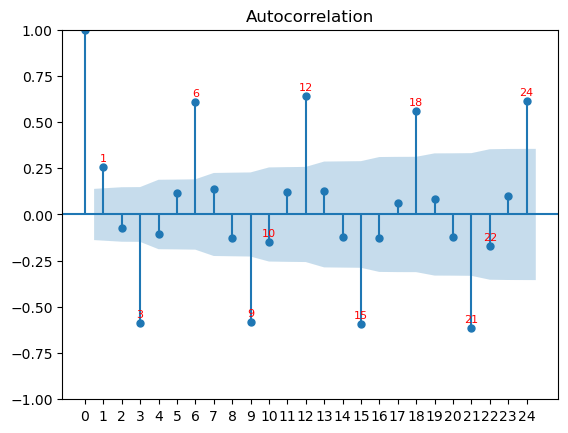

In [126]:
from statsmodels.tsa.stattools import acf
import numpy as np

fig, ax = plt.subplots()
plot_acf(res.resid, lags=24, ax=ax)
ax.xaxis.set_ticks(range(0, 25, 1))

banda = 1.96 / np.sqrt(len(res.resid))
valores_acf = acf(res.resid, nlags=24)

for lag, valor in enumerate(valores_acf):
    if abs(valor) > banda and lag > 0:
        ax.text(lag, valor + 0.03, str(lag),
                ha='center', fontsize=8, color='red')

plt.show()